In [6]:

import pandas as pd

order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
category_translation = pd.read_csv("../data/product_category_name_translation.csv")

print("ORDER ITEMS")
display(order_items.head(5))

print("PRODUCTS")
display(products.head(5))

print("CATEGORY TRANSLATION")
display(category_translation.head(5))

ORDER ITEMS


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


PRODUCTS


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


CATEGORY TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [7]:

# 1. Hər DataFrame-in ölçüsü
print("Order items:", order_items.shape)
print("Products:", products.shape)
print("Category translation:", category_translation.shape)

# 2. Sütun adları
print("\nOrder items columns:")
print(order_items.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

print("\nCategory translation columns:")
print(category_translation.columns.tolist())

# 3. Boş dəyərlərin sayı
print("\nOrder items missing values:")
print(order_items.isnull().sum())

print("\nProducts missing values:")
print(products.isnull().sum())

print("\nCategory translation missing values:")
print(category_translation.isnull().sum())

Order items: (112650, 7)
Products: (32951, 9)
Category translation: (71, 2)

Order items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Products columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Category translation columns:
['product_category_name', 'product_category_name_english']

Order items missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products missing values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_h

In [9]:
order_products= pd.merge(order_items,products, on="product_id",how="left")

#neticeni kategoriya tercumesi ile birlesdirek 

sales_data=pd.merge(order_products,category_translation, left_on="product_category_name", right_on="product_category_name", how="left")

#ilk 5 setir
display(sales_data.head(5))

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [10]:
sales_data.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english']

In [13]:
#Mərhələ 4 — Məhsul kateqoriyası məlumatlarının yoxlanılması

product_category_counts = sales_data['product_category_name_english'].value_counts()  
product_category_counts_n = sales_data['product_category_name_english'].nunique()  
display(product_category_counts_n)

product_category_counts_null_values = sales_data['product_category_name_english'].isnull().sum()
display(product_category_counts_null_values)

71

np.int64(1627)

sales_data DataFrame-indəki price sütununu təhlil et

In [14]:
maks=sales_data['price'].max()
minimum=sales_data['price'].min()
ortalama=sales_data['price'].mean()
median=sales_data['price'].median()
display(maks, minimum, ortalama, median)

np.float64(6735.0)

np.float64(0.85)

np.float64(120.65373901464713)

np.float64(74.99)

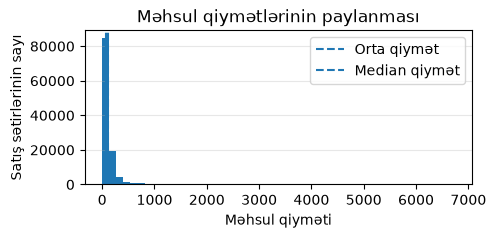

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 2))

plt.hist(sales_data['price'], bins=50)

plt.axvline(
    sales_data['price'].mean(),
    linestyle='--',
    label='Orta qiymət'
)

plt.axvline(
    sales_data['price'].median(),
    linestyle='--',
    label='Median qiymət'
)

plt.title('Məhsul qiymətlərinin paylanması')
plt.xlabel('Məhsul qiyməti')
plt.ylabel('Satış sətirlərinin sayı')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()